# Advanced: Multi-Dimensional Cloud Experiment

In this notebook, we'll explore pyRadtran's multi-processing capabilities by running simulations across multiple parameter dimensions simultaneously — varying cloud water content, effective radius, surface albedo, and more in a single batch.

## Overview

A core design principle of pyRadtran is the ability to run many simulations in parallel and then analyze the results using xarray's handling of named dimensions. This means multi-dimensional simulation sweeps (e.g., varying cloud properties, surface albedo, and atmospheric conditions) fit naturally into the xarray paradigm and can be explored with its powerful selection, aggregation, and plotting tools.

Here we simulate clear-sky and cloudy radiative transfer over four Arctic surface types, sweeping across a range of liquid water contents (LWC). We then compute the **Cloud Radiative Effect (CRE)** — the difference between cloudy and clear-sky net irradiance — for both the solar and thermal spectral ranges.

In [1]:
import pyradtran  # Registers the .pyradtran xarray accessor
from pyradtran import load_config
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

# ── Solar config: broadband solar 300–3000 nm ─────────────────────────────────
cfg_solar = load_config()
cfg_solar.simulation_defaults.rte_solver           = "disort"
cfg_solar.simulation_defaults.mol_abs_param        = "reptran coarse"
cfg_solar.simulation_defaults.source               = "solar"
cfg_solar.simulation_defaults.wavelength_nm        = [300, 3000]
cfg_solar.simulation_defaults.integrate_wavelength = True
cfg_solar.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo", "heat"]
cfg_solar.execution.max_workers                    = 30
cfg_solar.execution.cleanup_temp_files             = False
cfg_solar.execution.timeout_seconds                = 3600
solar_config_path = Path("config/arctic_cloud_experiment_solar.yaml")
cfg_solar.to_yaml(solar_config_path)

# ── Thermal config: broadband thermal 3–100 µm ───────────────────────────────
cfg_thermal = load_config()
cfg_thermal.simulation_defaults.rte_solver           = "disort"
cfg_thermal.simulation_defaults.mol_abs_param        = "reptran coarse"
cfg_thermal.simulation_defaults.source               = "thermal"
cfg_thermal.simulation_defaults.wavelength_nm        = [3000, 100000]
cfg_thermal.simulation_defaults.integrate_wavelength = True
cfg_thermal.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo", "heat"]
cfg_thermal.execution.max_workers                    = 30
cfg_thermal.execution.cleanup_temp_files             = False
cfg_thermal.execution.timeout_seconds                = 3600
thermal_config_path = Path("config/arctic_cloud_experiment_thermal.yaml")
cfg_thermal.to_yaml(thermal_config_path)

print(f"Solar config:   {solar_config_path}")
print(f"Thermal config: {thermal_config_path}")

2026-04-19 01:24:47,973 - pyradtran.config - INFO - Configuration written to config/arctic_cloud_experiment_solar.yaml
2026-04-19 01:24:47,977 - pyradtran.config - INFO - Configuration written to config/arctic_cloud_experiment_thermal.yaml


Solar config:   config/arctic_cloud_experiment_solar.yaml
Thermal config: config/arctic_cloud_experiment_thermal.yaml


## Surface Properties

We consider four Arctic surface types spanning a wide range of shortwave albedo and longwave emissivity:

| Surface type             | Shortwave albedo α (broadband) | Longwave emissivity ε (8–13 µm) | Notes                                        |
|--------------------------|--------------------------------|----------------------------------|----------------------------------------------|
| Open water               | 0.05 – 0.10                   | 0.985 – 0.990                   | Low SW reflectance; near-blackbody in TIR    |
| Thin ice (nilas / young) | 0.15 – 0.40                   | 0.970 – 0.985                   | Strong thickness dependence; key for leads   |
| Snow-covered sea ice     | 0.75 – 0.90                   | 0.980 – 0.995                   | Very high SW albedo; excellent LW emitter    |

In [2]:
albedos_sw = [0.07, 0.3, 0.75, 0.9]
albedos_lw = [1 - 0.987, 1 - 0.985, 1 - 0.98, 1 - 0.991]  # albedo = 1 - emissivity

## Build the Input Dataset and Run Simulations

We construct an `xr.Dataset` with dimensions for liquid water content (`lwc`), effective radius (`reff`), and surface albedo (`albedo`). Each combination is simulated in both the solar and thermal spectral ranges, for clear-sky and cloudy conditions — four batch runs in total.

In [3]:
# Cloud and atmospheric parameters
lwcs = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50]
reffs = [10]
surface_temperatures = [273.15, 273.15 - 5, 253.15 - 20, 273.15 - 25]
cbh = [0.5] * len(lwcs)
cth = [1.5] * len(lwcs)

times = pd.date_range("2024-04-04 12:00", periods=1, freq="h")
lats = [78] * len(times)
lon = [0] * len(times)
altitudes = np.arange(0, 10, 1)

ds = xr.Dataset(
    coords={
        "time": times,
        "latitude": (("time",), lats),
        "longitude": (("time",), lon),
        "altitude": (("altitude",), altitudes),
    },
    data_vars={
        "lwc": (("lwc",), lwcs),
        "reff": (("reff",), reffs),
        "cth": (("lwc",), cth),
        "cbh": (("lwc",), cbh),
        "surface_temperature": (("albedo",), surface_temperatures),
        "albedo_sw": (("albedo",), albedos_sw),
        "albedo_lw": (("albedo",), albedos_lw),
    },
)

# Clear-sky solar
ds_sim_no_cloud_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    save_to_file=False,
    return_dataset=True,
    show_progress=False,
)

# Clear-sky thermal
ds_sim_no_cloud_thermal = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_thermal.yaml',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_lw',
    save_to_file=False,
    return_dataset=True,
    show_progress=False,
)

# Cloudy solar
ds_sim_cloudy_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    save_to_file=False,
    return_dataset=True,
    show_progress=False,
)

# Cloudy thermal
ds_sim_cloudy_thermal = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_thermal.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_lw',
    save_to_file=False,
    return_dataset=True,
    show_progress=False,
)

## Compute Cloud Radiative Effect (CRE)

The Cloud Radiative Effect is defined as the difference in net irradiance between cloudy and clear-sky conditions:

$$\text{CRE} = F_{\text{net}}^{\text{cloudy}} - F_{\text{net}}^{\text{clear}}$$

We compute CRE separately for the solar and thermal bands, then sum them to obtain the total CRE.

In [4]:
ds_sim_no_cloud_solar_normed = ds_sim_no_cloud_solar / 1000
ds_sim_cloudy_solar_normed = ds_sim_cloudy_solar / 1000
ds_cre_solar = ds_sim_cloudy_solar_normed - ds_sim_no_cloud_solar_normed
ds_cre_thermal = ds_sim_cloudy_thermal - ds_sim_no_cloud_thermal
ds_cre_total = ds_cre_solar + ds_cre_thermal

## Visualize Solar and Thermal Irradiance and CRE

The four-panel plot below shows the net irradiance at the surface for each spectral range (top row) and the corresponding CRE (bottom row), coloured by liquid water content.

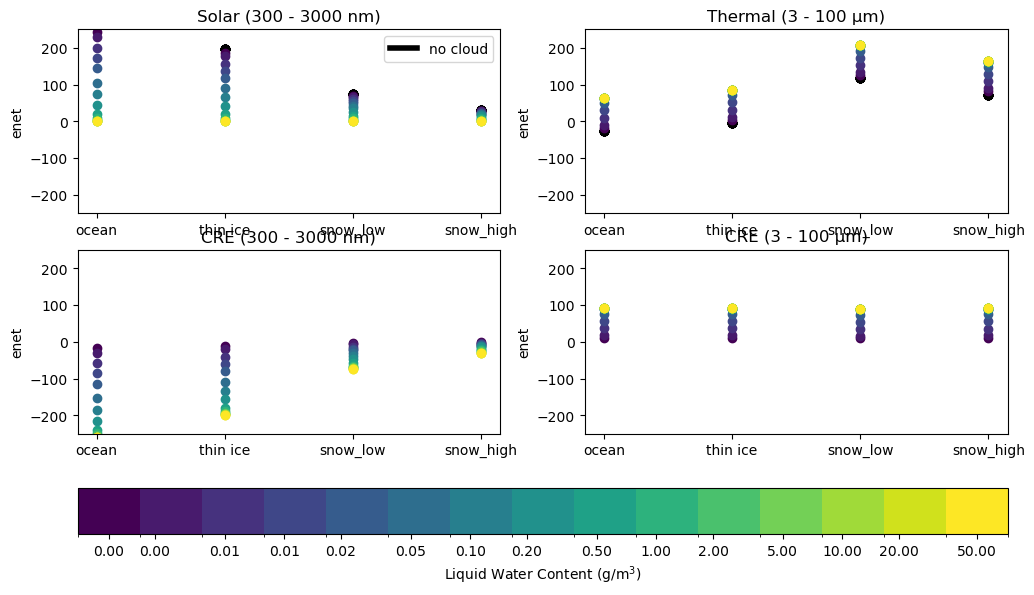

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7,))
from cycler import cycler

# change lwc hue with cycler to virdis colors
ax[0, 0].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_solar.lwc)))))
ax[0, 1].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_thermal.lwc)))))

(ds_sim_no_cloud_solar.isel(altitude=0).enet / 1000).plot(hue='lwc', color='k', ax=ax[0, 0], add_legend=False, marker='o', linestyle='')
(ds_sim_cloudy_solar.isel(altitude=0).enet / 1000).plot(hue='lwc', label='cloudy', ax=ax[0, 0], add_legend=False, marker='o', linestyle='')
ax[0,0].set_title('Solar (300 - 3000 nm)')

ds_sim_no_cloud_thermal.isel(altitude=0).enet.plot(hue='lwc', color='k', ax=ax[0, 1], add_legend=False, marker='o', linestyle='')
ds_sim_cloudy_thermal.isel(altitude=0).enet.plot(hue='lwc', label='cloudy', ax=ax[0, 1], add_legend=False, marker='o', linestyle='')
ax[0,1].set_title('Thermal (3 - 100 µm)')

ax[1, 0].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_solar.lwc)))))
ax[1, 1].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_solar.lwc)))))


ds_cre_solar.isel(altitude=0).enet.plot(hue='lwc', ax=ax[1, 0], add_legend=False, marker='o', linestyle='')
ds_cre_thermal.isel(altitude=0).enet.plot(hue='lwc', label='cloudy', ax=ax[1, 1], add_legend=False, marker='o', linestyle='')
ax[1,1].set_title('CRE (3 - 100 µm)')
ax[1,0].set_title('CRE (300 - 3000 nm)')



# add a colorbar to the bottom of the figure
import matplotlib.colors as mcolors

lwc_values = ds_sim_no_cloud_solar.lwc.values
n_colors = len(lwc_values)

# Create a colormap with discrete colors based on the viridis cycler
colors = plt.cm.viridis(np.linspace(0, 1, n_colors))
discrete_cmap = mcolors.ListedColormap(colors)

# Create boundaries for the discrete colormap
# Assuming lwc_values are ordered, calculate midpoints for boundaries
# If lwc_values are not ordered, sort them first: lwc_values.sort()
if n_colors > 1:
    boundaries = np.concatenate(([lwc_values[0] - (lwc_values[1] - lwc_values[0]) / 2],
                                 (lwc_values[:-1] + lwc_values[1:]) / 2,
                                 [lwc_values[-1] + (lwc_values[-1] - lwc_values[-2]) / 2]))
else: # Handle case with a single LWC value
    boundaries = np.array([lwc_values[0] - 0.5, lwc_values[0] + 0.5])


norm = mcolors.BoundaryNorm(boundaries, discrete_cmap.N, clip=True)

sm = plt.cm.ScalarMappable(cmap=discrete_cmap, norm=norm)
sm.set_array([]) # Required for ScalarMappable when not directly plotting data

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.15, pad=0.1, ticks=lwc_values)
cbar.set_label('Liquid Water Content (g/m$^3$)')

x_labels = ['ocean', 'thin ice', 'snow_low', 'snow_high']
x_ticks = np.arange(len(x_labels))

# add only a legend for the black line
handels = [plt.Line2D([0], [0], color='k', lw=4)]
labels = ['no cloud']
ax[0,0].legend(handels, labels, loc='upper right', ncol=1)

for a in ax.flatten():
    a.set_xticks(x_ticks)
    a.set_xticklabels(x_labels)
    a.set_xlabel('')
    a.set_ylim(-250, 250)   

### Interpretation

**Top row — Net Irradiance:** In the solar wavelength range, cloud presence generally reduces the downwelling radiation reaching low-albedo surfaces (open water) less than high-albedo surfaces (snow), because clouds increase the effective path length and multiple scattering. In the thermal wavelength range, clouds emit additional downwelling longwave radiation that warms the surface — an effect largely independent of surface albedo.

**Bottom row — CRE:** The solar CRE is negative (cooling) over dark surfaces and near zero or even slightly positive over highly reflective snow, where the cloud's albedo effect is less important. The thermal CRE is consistently positive (warming). These competing effects set the stage for understanding total CRE below.

## Total Cloud Radiative Effect by Surface Type

Combining the solar and thermal CRE reveals whether clouds produce net warming or cooling at the surface. The sign and magnitude depend strongly on the surface albedo and cloud optical thickness (driven here by LWC).

Text(0.5, 0, '')

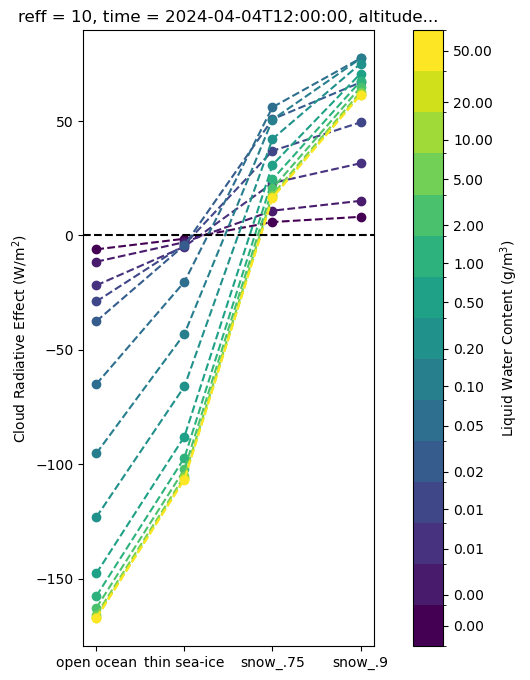

In [6]:
fig, ax = plt.subplots(figsize=(5, 8))

ax.set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim_no_cloud_solar.lwc)))))


ds_cre_total.isel(altitude=0).enet.plot(hue='lwc', marker='o', ax=ax, ls='--', add_legend=False )


ax.axhline(y=0, color='black', linestyle='--')

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['open ocean', 'thin sea-ice', 'snow_.75', 'snow_.9'])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.15, pad=0.1, ticks=lwc_values)
cbar.set_label('Liquid Water Content (g/m$^3$)')
ax.set_ylabel('Cloud Radiative Effect (W/m$^2$)')
ax.set_xlabel('')


### Interpretation

Over **open ocean** (low albedo), thin clouds produce a net warming effect because the thermal CRE dominates, while thick clouds can produce net cooling as the solar CRE becomes large and negative. Over **snow-covered surfaces** (high albedo), the solar CRE is small because the surface is already highly reflective, so clouds can produce net warming through their thermal emission.

This result highlights a key feature of Arctic climate: the cloud radiative effect is strongly modulated by the underlying surface. 